In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay

import tensorflow as tf

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/manuel/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/manuel/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

# Data Science Process

> CRISP-DM CRoss Industry Standard Process for Data Mining

![alt](../assets/Screenshot%202026-06-25%20at%2012.20.14.png)

# Step 1: Business Understanding

# Step 2: Data Understanding

Python-Setup mit UV und den notwendigen Abhängigkeiten eingerichtet.

> pyproject.toml als Dokumentation für die genutzten Pakete

```toml
[project]
name = "dhbw-neuekonzepte-portfolio"
version = "0.1.0"
description = "Add your description here"
readme = "README.md"
requires-python = ">=3.12"
dependencies = [
    "ipykernel>=7.2.0",
    "polars>=1.40.1",
    "pandas>=2.0.0",
    "matplotlib>=3.7.0",
    "seaborn>=0.13.0",
    "pyarrow>=14.0.0",
    "scikit-learn>=1.9.0",
    "nltk>=3.9.4",
]
```

### Datensatz - Emotion Detection from Text

> Gewählter Datensatz: https://www.kaggle.com/datasets/pashupatigupta/emotion-detection-from-text

**Autor:** Pashupati Gupta

Die Daten des Datensatzes sind ein öffentlicher Auszug aus einem größeren unveröffentlichten  Datensatz der Plattform data.world. Nach Angaben des Authors wurden die Emotionsklassen manuell annotiert.

## 2.1. Business Understanding

## 2.2. SMART-Ziele

### SMART Ziele (TODO: Olaf)

**Forschungsfrage:** Lassen sich die in kurzen Tweets ausgedrückten Emotionen mit klassischen Machine-Learning-Verfahren zuverlässig automatisch klassifizieren? Welches Modell liefert die beste Vorhersagequalität?

| | Begriff | Bedeutung |
|---|---|---|
| **S** | `⁠Spezifisch⁠` | Emotionen werden durch ML Verfahren klassifiziert. Das für die Klassifizierung am besten geeignete Modell wird hierzu gesucht. |
| **M** | `⁠Messbar` | Das beste Modell erzielt den höchsten F1-Score (macro). |
| **A** | `⁠Attraktiv ` | Durch die fachlich korrekte Anwendung der in der VL vermittelten Methoden wird das Verständniss von Data Science Methoden geschuhlt und verstanden.|
| **R** | `⁠Realistisch` | Der Datensatz sowie die ML-Verfahren sind in der VL-Unterlagen aufgelistet und erläutert. |
| **T** | ⁠`Terminiert`⁠ | Das Notebook wird bis zum 02.07.26 fertigestellt |

**Ziel:** ⁠Den gewählten Datensatz analysieren und nutzbar aufbereiten um die Modellvorhersagen zu ermöglichen.

## 3.1 Data Understanding

### Datensatz einlesen

In [ ]:
df = pd.read_csv('../data/csv/tweet_emotion_dataset.csv')   # Datensatz in CSV Format einlesen
df = df.drop(columns=['tweet_id'])                          # Spalte 'tweet_id' entfernen
df.columns = ['emotion', 'content']                         # Spalten umbenennen

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   emotion  40000 non-null  str  
 1   content  40000 non-null  str  
dtypes: str(2)
memory usage: 3.7 MB


In [ ]:
df

Der gewählte Datensatz enthält 40.000 Zeilen sowie 3 Spalten. Spalte 1 (tweet_id) wird nicht benötigt und wurde daher entfernt. Spalte 2 enhält die Emotionsklasse zu der in Spalte 3 enthaltenten Kurznachricht (content).

Der Datensatz ist aufgrund seiner Einfachheit (Nur 2 relevante Spalten mit String-Werten) intuitiv verständlich. 

In [ ]:
df.describe()

### Visualisierung der Zielvariablen

In [ ]:
values = df["emotion"].value_counts()
labels = values.index
colors = plt.cm.tab10.colors

pct_labels = [f"{l} ({v/values.sum()*100:.1f}%)" for l, v in zip(labels, values)]

fig, (ax_bar, ax_pie) = plt.subplots(1, 2, figsize=(16, 6))

bars = ax_bar.bar(labels, values, color=colors[:len(labels)])
ax_bar.set_title("Verteilung der Zielvariable 'emotion'", fontsize=14)
ax_bar.set_xlabel("Emotion")
ax_bar.set_ylabel("Anzahl")
ax_bar.tick_params(axis="x", rotation=45)
ax_bar.spines[:].set_visible(False)
_ = ax_bar.bar_label(bars, padding=5, fontsize=8)

wedges, _ = ax_pie.pie(values, colors=colors[:len(labels)], startangle=140)
ax_pie.set_title("Anteil der Emotionsklassen", fontsize=13)
ax_pie.legend(wedges, pct_labels, loc="center left", bbox_to_anchor=(1, 0.5), fontsize=9)

plt.tight_layout()
plt.show()

- **Klassenungleichgewicht**: `neutral` (21,6 %) und `worry` (21,1 %) dominieren; `anger` hat nur 110 Einträge (0,3 %).
- TODO: *Die **Textlänge** variiert kaum zwischen den Emotionsklassen und ist daher kein Merkmal der Emotion.*
- Für das spätere Modell muss dieses Ungleichgewicht berücksichtigt

# Step 3: Data Preperation

## 3.4. Regex

| Schritt | Regex-Pattern | Beschreibung |
|---------|---------------|--------------|
| Kleinschreibung | `.lower()` | Vereinheitlichung Groß-/Kleinschreibung |
| URLs entfernen | `https?://\S+\|www\.\S+` | HTTP/HTTPS-Links und www-Adressen |
| Mentions entfernen | `@\w+` | Twitter-Nutzernamen wie `@user` |
| Hashtag-Symbol entfernen | `#` | Nur das `#`-Zeichen, das Wort bleibt erhalten |
| Sonderzeichen entfernen | `[^\w\s]` | Punkte, Kommas, Ausrufezeichen etc. |
| Zahlen entfernen | `\d+` | Reine Ziffernfolgen |
| Leerzeichen normalisieren | `\s+` → `' '` | Mehrfache Leerzeichen auf eines reduzieren |

Normalisierung, Skalierung und Standardisierung ist für unseren Datensatz nicht relevant, da es sich um textuelle Daten handelt, welche im folgenden sowieso durch Tokenisierung, Vektorisierung etc. weiterverarbeitet werden müssen. Eine verzeitige Normalisierung ist daher nicht notwendig. Normalisierung im Sinne von Lemmatisierung könnte angewendet werden.

In [ ]:
token = df.content.str.lower()                                         # Text in Kleinbuchstaben umwandeln
token = token.str.replace(r'https?://\S+|www\.\S+', '', regex=True)   # Hyperlinks entfernen
token = token.str.replace(r'@\w+', '', regex=True)                    # Nutzererwähnungen entfernen
token = token.str.replace(r'#', '', regex=True)                       # Nur das Hashtag-Symbol entfernen
token = token.str.replace(r'[^\w\s]', '', regex=True)                 # Sonderzeichen entfernen
token = token.str.replace(r'\d+', '', regex=True)                     # Ziffern/Zahlen entfernen
token = token.str.replace(r'\s+', ' ', regex=True).str.strip()        # Doppelte Leerzeichen entfernen
df["token"] = token

## 4.1. Datenqualität

In [ ]:
df.describe()

,emotion,content,tokens
count,40000,40000,40000
unique,13,39827,38998
top,neutral,I just received a mothers day card from my lov...,
freq,8638,14,99


### 4.1.1 Fehlende Werte

In [ ]:
df.isna().sum()

emotion    0
content    0
tokens     0
dtype: int64

In [ ]:
df.isnull().sum()

emotion    0
content    0
tokens     0
dtype: int64

Keine fehlende oder null Werte, die entfernt werden müssten...

In [ ]:
df.info()
df[df.token == ""]

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   emotion  40000 non-null  str  
 1   content  40000 non-null  str  
 2   tokens   40000 non-null  str  
dtypes: str(3)
memory usage: 6.3 MB


,emotion,content,tokens
340,empty,0,
659,neutral,@Joshuah_Pearson,
664,neutral,@emlevins,
2621,surprise,@swpave ?????????????,
3181,neutral,@Clumsyflic,
...,...,...,...
38650,neutral,@Britt_Uh_Knee,
39206,neutral,@hmigroupllc,
39415,neutral,0,
39518,neutral,@Remy_Foster,


ABER: 99 Nachrichten sind durch den Regex filter leer geworden, und werden im Folgenden entfernt:

In [ ]:
df = df[df.token != ""]        # Zeilen mit leeren token entfernen

In [ ]:
df.info()
df[df.token == ""]

<class 'pandas.DataFrame'>
Index: 39901 entries, 0 to 39999
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   emotion  39901 non-null  str  
 1   content  39901 non-null  str  
 2   tokens   39901 non-null  str  
dtypes: str(3)
memory usage: 6.6 MB


,emotion,content,tokens


### 4.1.2 Duplikate

In [ ]:
df[df.duplicated(subset="content", keep=False)]

,emotion,content,tokens
51,worry,why am i so tired?,why am i so tired
147,relief,I'm at work,im at work
324,sadness,I feel so deflated. No more doggy.,i feel so deflated no more doggy
366,worry,I feel so deflated. No more doggy.,i feel so deflated no more doggy
454,worry,Somebody please save the polar bears!,somebody please save the polar bears
...,...,...,...
39859,love,Happy Mothers Day,happy mothers day
39898,love,happy mothers day!,happy mothers day
39913,happiness,happy mother's day!,happy mothers day
39915,love,happy mother's day everyone,happy mothers day everyone


254 Nachrichten bzw. deren Tokenfolge sind Duplikate, welche im Folgenden entfernt werden:

In [ ]:
df = df.drop_duplicates(subset="content", keep=False)    # Entfernen von Duplikaten

In [ ]:
df.info()
df[df.content.duplicated(keep=False)]

<class 'pandas.DataFrame'>
Index: 39647 entries, 0 to 39999
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   emotion  39647 non-null  str  
 1   content  39647 non-null  str  
 2   tokens   39647 non-null  str  
dtypes: str(3)
memory usage: 6.6 MB


,emotion,content,tokens


In [ ]:
df.tail()

,emotion,content,tokens
39994,happiness,Succesfully following Tayla!!,succesfully following tayla
39996,love,Happy Mothers Day All my love,happy mothers day all my love
39997,love,Happy Mother's Day to all the mommies out ther...,happy mothers day to all the mommies out there...
39998,happiness,@niariley WASSUP BEAUTIFUL!!! FOLLOW ME!! PEE...,wassup beautiful follow me peep out my new hit...
39999,love,@mopedronin bullet train from tokyo the gf ...,bullet train from tokyo the gf and i have been...


### 4.1.4 Weitere Qualitätsprobleme

Der Datensatz enthält 13 Emotionsklassen, die sehr ungleich verteilt sind. Die fünf häufigsten Klassen (neutral, worry, happiness, sadness, love) machen zusammen bereits rund 76 % aller Tweets aus (30.464 von 38.998), während die übrigen acht Klassen nur sehr selten vorkommen: `anger`⁠ z.B. mit nur 110 Einträgen (0,3 %).

So wenige Beispiele reichen nicht, damit ein Modell diese seltenen Emotionen zuverlässig lernen kann. Das starke Klassenungleichgewicht würde die Vorhersagequalität verschlechtern und die Ergebnisse verzerren. Durch die Fokussierung auf die **Top-5-Klassen** erhalten wir ein ausgewogeneres und besser lernbares Klassifikationsproblem, ohne den Großteil der Daten zu verlieren.

**Die Top-5-Klassen:**

1. `Neutral`
2. `Worry`
3. `Hapiness`
4. `Sadness`
5. `Love`

In [ ]:
keep = ["neutral", "worry", "happiness", "sadness", "love"]     # Filter auf Top5 Emotionsklassen
df_filtered = df[df.emotion.isin(keep)]
df_filtered = df_filtered.groupby("emotion").sample(n=3842, replace=True, random_state=42).reset_index(drop=True)

print(f"Verbleibende Klassen: {keep}")
print(f"Anteil am Gesamtdatensatz: {len(df) / 40000 * 100:.1f}%")
print(f"Verbleibende Einträge: {len(df_filtered)}")
print(f"Gelöschte Einträge: {len(df) - len(df_filtered)}")

df = df_filtered

Verbleibende Klassen: ['neutral', 'worry', 'happiness', 'sadness', 'love']
Anteil am Gesamtdatensatz: 99.1%
Verbleibende Einträge: 19210
Gelöschte Einträge: 20437


In [ ]:
print(df.emotion.value_counts())

emotion
happiness    3842
love         3842
neutral      3842
sadness      3842
worry        3842
Name: count, dtype: int64


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19210 entries, 0 to 19209
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   emotion  19210 non-null  str  
 1   content  19210 non-null  str  
 2   tokens   19210 non-null  str  
dtypes: str(3)
memory usage: 3.0 MB


## 5.1 Beschreibung des Korpus ( Aufgabe 5.1)

Unser Korpus ist die Sammlung von Tweets in englischer Sprache. 

Die Tweets sind alle auf Englisch. Jeder Tweet ist ein eigener Eintrag mit einer zugeordneten Emotion. Nach der Bereinigung und der Beschränkung auf die fünf Klassen besteht unser Korpus aus 19.210 Tweets.

Der Text wird nachfolgend weiter optimiert: Stopwords wie „the", „and" oder „is" werden entfernt, Wörter auf ihren Wortstamm gekürzt (Lemmatisierung).

+ Word Types: 15.904
+ Word Instances: 115.313

## 5.2. Wortfrequenzanalyse

Whitespace Tokenisierung

In [ ]:
df["token"] = df["token"].str.split()     # Whitespace Tokenisierung eigener Spalte

In [ ]:
df.tail()

,emotion,content,tokens
19205,worry,Good mornin &amp; no u tol twitter LOL but I k...,"[good, mornin, amp, no, u, tol, twitter, lol, ..."
19206,worry,@penbleth Don't leave forever! We'll miss you ...,"[dont, leave, forever, well, miss, you, too, m..."
19207,worry,transferring 368558682 photos is annoying.. I ...,"[transferring, photos, is, annoying, i, want, ..."
19208,worry,@alex_lpz yeah text me!!! i wnat to go!!!!! bu...,"[yeah, text, me, i, wnat, to, go, but, my, car..."
19209,worry,@thecapillary i noticed that you were on the s...,"[i, noticed, that, you, were, on, the, same, h..."


### 5.2.3 Barchart Visualisierung

Anzahl Token (insgesamt):  238360
Anzahl einzigartiger Token |V|: 17302


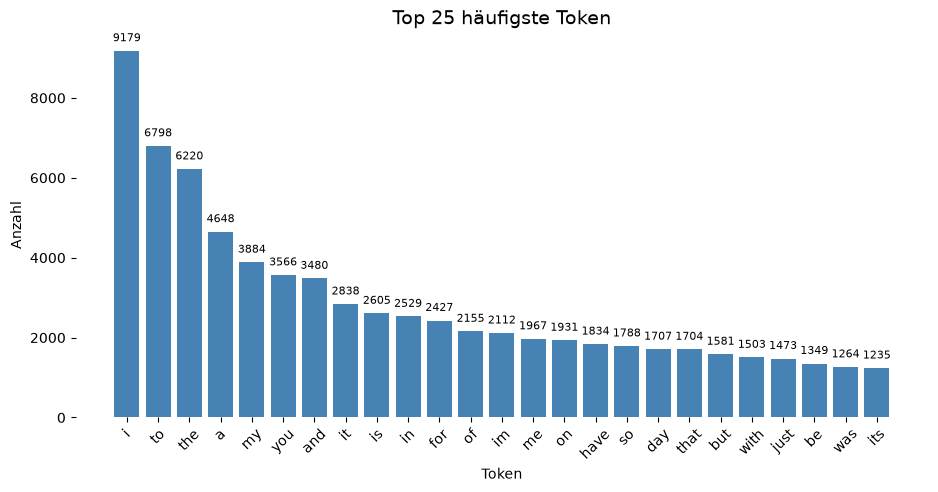

In [ ]:
def plot_top_words(top_n=25):
    word_list = np.concatenate(df.token.values)

    word_counts = pd.Series(word_list).value_counts()
    word_counts = word_counts.reset_index()
    word_counts.columns = ["word", "count"]

    print("Anzahl Token (insgesamt): ", len(word_list))
    print("Anzahl einzigartiger Token |V|:", len(word_counts.word))

    top_words = word_counts.head(top_n)

    _, ax = plt.subplots(figsize=(11, 5))
    bars = ax.bar(top_words["word"], top_words["count"], color="steelblue")
    ax.set_title(f"Aufgabe 5.2.3 - Top {top_n} häufigste Token", fontsize=14)
    ax.set_xlabel("Token")
    ax.set_ylabel("Anzahl")
    ax.tick_params(axis="x", rotation=45)
    ax.spines[:].set_visible(False)
    _ = ax.bar_label(bars, padding=5, fontsize=8)
    plt.show()

plot_top_words()

Die Wortfrequenzanalyse zeigt, dass die häufigsten Wörter im Korpus wie „im", „day", „good" oder „go" haben keinen emotionalen oder inhaltlichen Mehrwert. Ihr hohes Aufkommen im gesamten Datensatz macht sie zu Stopwords, die im folgenden Schritt gefiltert werden sollten.

### 5.2.5 Stopwords entfernen

In [ ]:
stop_words = set(stopwords.words("english"))

print("Anzahl von Stopwords: " + str(len(stop_words)))
print("Stopwords: " + str(stop_words))

Anzahl von Stopwords: 198
Stopwords: {'i', 'themselves', 'whom', "didn't", 'were', 'further', "mustn't", 'by', 'yourselves', "he's", 'here', 'now', 'other', 'is', 'shan', "you're", 're', 'how', 'that', 'once', 'then', 'he', 'y', 'same', 'as', 'was', 'yours', 'before', 'needn', 'ma', 'for', 'hers', "it'll", "haven't", 'each', 'haven', 'won', "shan't", 'just', 'when', 'ours', 'those', 'what', 'the', 'through', "hadn't", "doesn't", 'until', "wouldn't", 'ourselves', "it'd", "they'll", 'will', 'him', 'your', 'all', "she'll", 'some', 'she', "wasn't", 'which', 's', "we'll", 'being', 'up', 'm', 've', 'be', 'd', 'more', 'shouldn', 'than', 'had', "you've", 'most', 'but', 'don', 'been', 'should', 'to', "don't", "they're", 'weren', 'their', 'where', 'during', 'from', 'doing', 'are', "weren't", 'ain', 'such', 'am', 'having', 'why', 'both', 'own', "won't", 'and', "i've", 'couldn', 'aren', 'll', 'only', 'no', 'nor', 'these', 'on', 'any', 'hadn', 'do', "needn't", 'very', 'it', 'our', 'under', 't', 'is

In [ ]:
df.token = df.token.apply(lambda t: [w for w in t if w not in stop_words])  # Stopwords entfernen

In [ ]:
def top_words_all(n=30):
    return pd.DataFrame([{
        "emotion": emotion,
        "top_words": pd.Series(
            np.concatenate(df[df["emotion"] == emotion]["token"].values)
        ).value_counts().head(n).index.tolist()
    } for emotion in df["emotion"].unique()]).set_index("emotion")

top_words_all()

,top_words
emotion,
happiness,"[good, day, im, happy, thanks, great, lol, got..."
love,"[love, day, happy, mothers, im, good, u, like,..."
neutral,"[im, like, get, go, dont, day, work, today, go..."
sadness,"[im, sad, day, miss, go, work, cant, like, get..."
worry,"[im, cant, get, dont, day, like, go, going, wo..."


Standard-Stopwords wurden erfolgreich entfernt. Es bleiben jedoch weiterhin Wörter, die gleichermaßen häufig in allen Klassen auftreten (z. B. „im", „day", „go"). Diese werden im nächsten Schritt durch eine iterative Schleife zusätzlich entfernt.

In [ ]:
# Iterativ klassenübergreifende Top30-Wörter entfernen, bis keine Schnittmenge mehr übrig bleibt

while True:
    common = set.intersection(*[set(w) for w in top_words_all().top_words])  # Schnittmenge der Top30-Wörter aller Klassen
    if not common:  # Stoppen, wenn keine Schnittmenge gefunden
        break
    df.token = df.token.apply(lambda t: [w for w in t if w not in common])
    print("Removed:", common)

Removed: {'get', 'go', 'know', 'time', 'got', 'day', 'u', 'today', 'im', 'one', 'good', 'like'}
Removed: {'amp', 'night', 'going', 'really', 'cant', 'lol', 'see'}
Removed: {'work', 'thats', 'think', 'well', 'dont', 'back', 'much'}
Removed: {'ill', 'new', 'love', 'home'}
Removed: {'tomorrow'}


Anzahl Token (insgesamt):  115313
Anzahl einzigartiger Token |V|: 17133


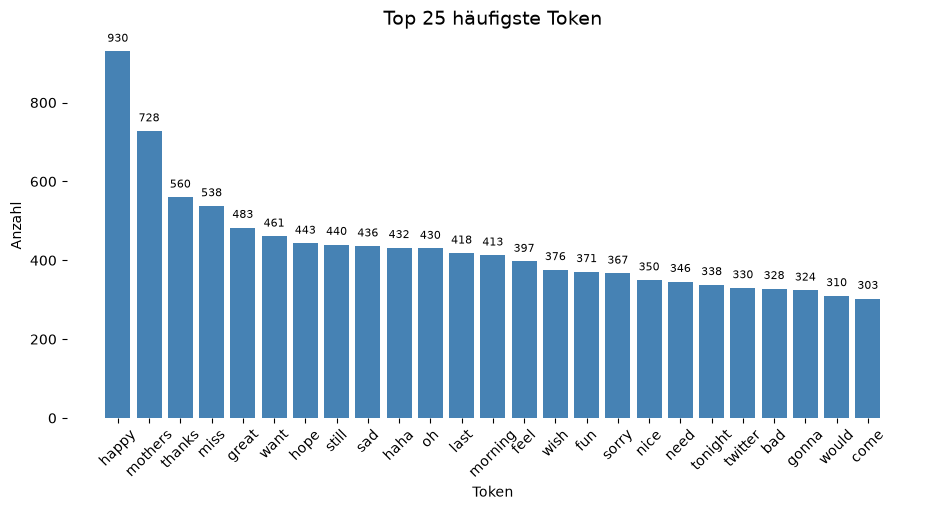

In [25]:
plot_top_words()

### 5.2.6 Byte Pair Encoding




Anzahl BPE-Tokens (insgesamt): 141874
Anzahl einzigartiger BPE-Tokens |V|: 12256

Beispiel:
  Original:   finally plugged listen flashpoints http shoutout missed segment chevron
  BPE-Tokens: ['finally', 'plu', 'gged', 'listen', 'flash', 'point', 'sh', 'tt', 'p', 'shoutout', 'missed', 'segment', 'chev', 'ron']


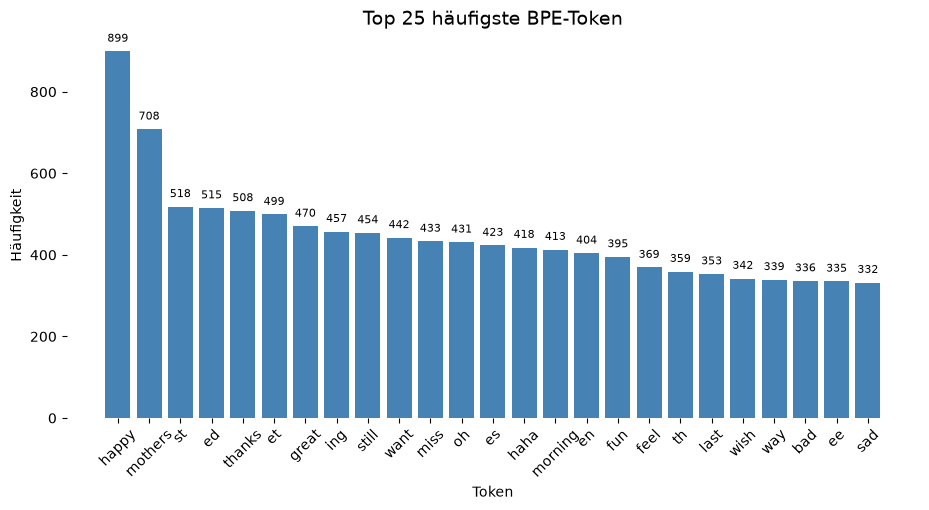

In [ ]:
tokenizer = Tokenizer(BPE())
tokenizer.train_from_iterator(df.token.tolist(), BpeTrainer(vocab_size=15000))

bpe_corpus = df.token.apply(" ".join)

# Alle Tweets codieren und Häufigkeiten zählen
all_token = []
for sentence in bpe_corpus:
    all_token.extend(tokenizer.encode(sentence).token)

print(f"Anzahl BPE-token (insgesamt): {len(all_token)}")
print(f"Anzahl einzigartiger BPE-token |V|: {len(set(all_token))}")

# Beispiel
print(f"\nBeispiel:")
print(f"  Original:   {bpe_corpus.iloc[0]}")
print(f"  BPE-token: {tokenizer.encode(bpe_corpus.iloc[0]).token}")

# Barchart Top 25
top_n = 25
token_freq = pd.Series(all_token).value_counts()
top_token = token_freq.head(top_n)

_, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(top_token.index, top_token.values, color="steelblue")
ax.set_title(f"Top {top_n} häufigste BPE-Token", fontsize=14)
ax.set_xlabel("Token")
ax.set_ylabel("Häufigkeit")
ax.tick_params(axis="x", rotation=45)
ax.spines[:].set_visible(False)
_ = ax.bar_label(bars, padding=5, fontsize=8)
plt.show()

Byte Pair Encoding (BPE) arbeitet nicht auf Wortebene, sondern auf Zeichenebene. Es startet mit einzelnen Zeichen und fasst schrittweise die häufigsten Zeichenpaare zu Teilwörtern zusammen. 

Je nach konfigurierter Vocabulary Size sinkt die Anzahl der Word Types da seltene Wörter in wiederverwendbare Teilwörter zerlegt werden. Gleichzeitig steigt die Zahl der Word Instances, weil Wörter nun aus mehreren Teilwörtern bestehen können.

- **Niedrig** (z. B. 500): Die meisten Wörter werden in Einzelzeichen aufgeteilt.
- **Mittel** (z. B. 5000, siehe Barchart): Häufige Wörter bleiben erhalten, seltene werden in geteilt.
- **Hoch** (z. B. 28000, ca. ursprüngliches Vokabular): Fast alle Wörter bleiben ganz. Kaum Unterschied zur Whitespace Tokenisierung.

`s` wird zum am häufig auftretenden Token. Wörter mit Endung auf `s` (z. B. „feels", „says") werden als Stamm + `s` gespeichert.

Für unseren Anwendungsfall mit klassischen Machine Learning Klassifikatoren sowie Deep Learning, bietet BPE keinen Mehrwert. Die Zerlegung in Teilwörter reduziert die Aussagekraft der Features. BPE wird daher im weiteren Verlauf nicht verwendet.

### Lemmatisierung

In [ ]:
lemmatizer = WordNetLemmatizer()
df["token"] = df.token.apply(lambda token: [lemmatizer.lemmatize(w) for w in token])

Anzahl Token (insgesamt):  115313
Anzahl einzigartiger Token |V|: 15904


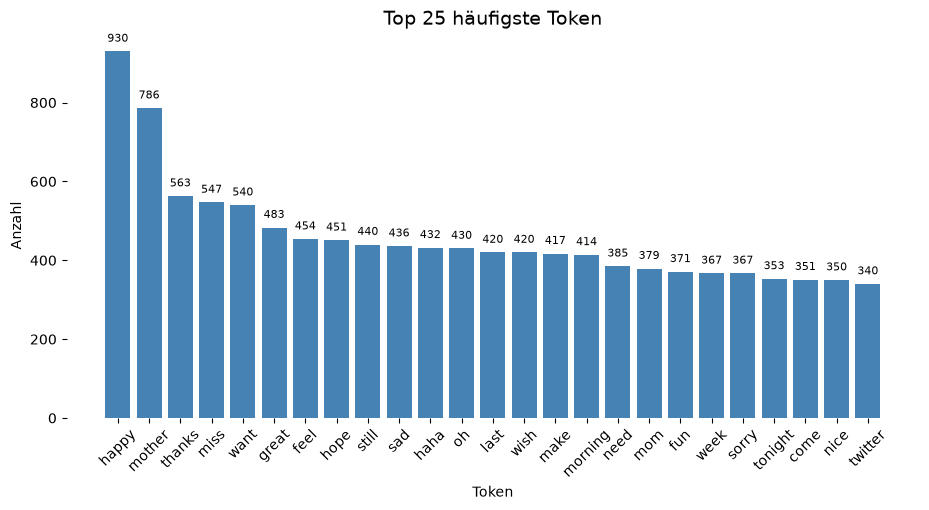

In [28]:
plot_top_words()

Lemmatisierung reduziert jedes Wort auf seine Grundform (Lemma) anhand eines Wörterbuchs: z. B. „running" → „run", „says" → „say", „happier" → „happy".

**Warum Lemmatisierung statt BPE?**

BPE zerlegt Wörter in Teilwörter und erzeugt damit Features wie `happ`, `iness` oder `s`. Lemmatisierung dagegen fasst bedeutungsgleiche Wortformen zusammen (`happy`, `happier`, `happiest` → `happy`) und reduziert so den Wortschatz ohne Informationsverlust.

---

Nach Datenaufbereitung kann der finale Datenkorpus definiert werden. Die zuvor durch Whitespace Tokenization erzeugte Tokenliste wird zur Modellierung wieder in einen String umgewandelt.

In [ ]:
corpus = df.token.apply(" ".join)

## 5.3 Vektorisierung

In [30]:
X = corpus
y = df.emotion

n_gram = (1, 2)

### 5.3.1 Bag-of-Words (`CountVectorizer`)

In [31]:
count_vectorizer = CountVectorizer(min_df=5, max_df=0.8)
X_count = count_vectorizer.fit_transform(X)

print("Anzahl der Features: " + str(count_vectorizer.get_feature_names_out().shape[0]))
print(X_count)

Anzahl der Features: 3178
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 90653 stored elements and shape (19210, 3178)>
  Coords	Values
  (0, 1004)	1
  (0, 1618)	1
  (0, 2460)	1
  (0, 1786)	1
  (1, 1154)	1
  (1, 907)	1
  (1, 1246)	1
  (1, 1821)	2
  (2, 3086)	1
  (2, 1851)	2
  (2, 2652)	1
  (2, 2356)	1
  (3, 3144)	1
  (3, 3041)	1
  (3, 239)	1
  (3, 2783)	1
  (4, 3117)	1
  (4, 2363)	1
  (4, 2601)	1
  (4, 2858)	1
  (4, 604)	1
  (5, 954)	1
  (5, 2189)	1
  (5, 79)	1
  (5, 2724)	1
  :	:
  (19204, 2134)	1
  (19205, 417)	1
  (19205, 2900)	1
  (19205, 3151)	1
  (19205, 1949)	1
  (19205, 200)	1
  (19205, 1523)	1
  (19205, 976)	1
  (19205, 105)	1
  (19205, 1816)	1
  (19206, 1049)	1
  (19206, 1578)	1
  (19206, 1785)	1
  (19207, 3004)	1
  (19207, 3017)	1
  (19207, 2050)	1
  (19207, 103)	1
  (19208, 3144)	1
  (19208, 2748)	1
  (19208, 435)	1
  (19208, 368)	1
  (19209, 557)	1
  (19209, 1338)	1
  (19209, 3110)	1
  (19209, 1917)	1


In [32]:
count_vectorizer_ngram = CountVectorizer(ngram_range=n_gram, min_df=5, max_df=0.8)
X_count_ngram = count_vectorizer_ngram.fit_transform(X)

print("Anzahl der Features: " + str(count_vectorizer_ngram.get_feature_names_out().shape[0]))
print(X_count_ngram)

Anzahl der Features: 4096
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 98464 stored elements and shape (19210, 4096)>
  Coords	Values
  (0, 1191)	1
  (0, 2006)	1
  (0, 3106)	1
  (0, 2257)	1
  (1, 1400)	1
  (1, 1064)	1
  (1, 1520)	1
  (1, 2314)	2
  (1, 1530)	1
  (1, 2331)	1
  (2, 3958)	1
  (2, 2373)	2
  (2, 3363)	1
  (2, 2981)	1
  (3, 4044)	1
  (3, 3895)	1
  (3, 279)	1
  (3, 3541)	1
  (4, 4008)	1
  (4, 2991)	1
  (4, 3291)	1
  (4, 3635)	1
  (4, 708)	1
  (4, 3292)	1
  (5, 1118)	1
  :	:
  (19205, 496)	1
  (19205, 3687)	1
  (19205, 4059)	1
  (19205, 2519)	1
  (19205, 231)	1
  (19205, 1884)	1
  (19205, 1154)	1
  (19205, 120)	1
  (19205, 2301)	1
  (19206, 1248)	1
  (19206, 1956)	1
  (19206, 2247)	1
  (19207, 3816)	1
  (19207, 3847)	1
  (19207, 2632)	1
  (19207, 115)	1
  (19207, 3830)	1
  (19208, 4044)	1
  (19208, 3483)	1
  (19208, 516)	1
  (19208, 443)	1
  (19209, 655)	1
  (19209, 1658)	1
  (19209, 3993)	1
  (19209, 2468)	1


### 5.3.2 TF-IDF Ansatz (`TfidfVectorizer`)

In [33]:
tfidf_vectorizer = TfidfVectorizer(min_df=5, max_df=0.8)
X_tfidf = tfidf_vectorizer.fit_transform(X)

print("Anzahl der Features: " + str(tfidf_vectorizer.get_feature_names_out().shape[0]))
print(X_tfidf)

Anzahl der Features: 3178
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 90653 stored elements and shape (19210, 3178)>
  Coords	Values
  (0, 1004)	0.4240798305315314
  (0, 1618)	0.5028051163550289
  (0, 2460)	0.6357621727021403
  (0, 1786)	0.4039180264170036
  (1, 1154)	0.5178813105047982
  (1, 907)	0.42924404615885825
  (1, 1246)	0.3126050598415435
  (1, 1821)	0.6706911164078957
  (2, 3086)	0.3427948853503609
  (2, 1851)	0.7474028223691465
  (2, 2652)	0.4232501988394024
  (2, 2356)	0.38044704871331747
  (3, 3144)	0.44841475233832423
  (3, 3041)	0.5065604543975015
  (3, 239)	0.5895322474739617
  (3, 2783)	0.4413303129338109
  (4, 3117)	0.4550761038938336
  (4, 2363)	0.39515473422766184
  (4, 2601)	0.4415048416060477
  (4, 2858)	0.5115337234791397
  (4, 604)	0.424458714440239
  (5, 954)	0.4420114131483792
  (5, 2189)	0.4617596406473964
  (5, 79)	0.336849471773502
  (5, 2724)	0.4748563812894854
  :	:
  (19204, 2134)	0.8559128026849216
  (19205, 417)	0.32105829279517717
  

In [34]:
tfidf_vectorizer_ngram = TfidfVectorizer(ngram_range=n_gram, min_df=5, max_df=0.8)
X_tfidf_ngram = tfidf_vectorizer_ngram.fit_transform(X)

print("Anzahl der Features: " + str(tfidf_vectorizer_ngram.get_feature_names_out().shape[0]))
print(X_tfidf_ngram)

Anzahl der Features: 4096
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 98464 stored elements and shape (19210, 4096)>
  Coords	Values
  (0, 1191)	0.4240798305315314
  (0, 2006)	0.5028051163550289
  (0, 3106)	0.6357621727021403
  (0, 2257)	0.4039180264170036
  (1, 1400)	0.4341304240729517
  (1, 1064)	0.3598274276553725
  (1, 1520)	0.26205110021073513
  (1, 2314)	0.562228087559888
  (1, 1530)	0.30335182774773667
  (1, 2331)	0.4530579038493407
  (2, 3958)	0.3427948853503609
  (2, 2373)	0.7474028223691465
  (2, 3363)	0.4232501988394024
  (2, 2981)	0.38044704871331747
  (3, 4044)	0.44841475233832423
  (3, 3895)	0.5065604543975015
  (3, 279)	0.5895322474739617
  (3, 3541)	0.4413303129338109
  (4, 4008)	0.4037716623936758
  (4, 2991)	0.3506057175418218
  (4, 3291)	0.3917303992119064
  (4, 3635)	0.45386435396701097
  (4, 708)	0.37660602101621393
  (4, 3292)	0.46126610859736383
  (5, 1118)	0.4420114131483792
  :	:
  (19205, 496)	0.32105829279517717
  (19205, 3687)	0.24333943030

### 5.3.3 N-gram Ansatz

In [35]:
# Vektorisierer für Bigramme
ngram_vectorizer = CountVectorizer(ngram_range=(2, 4))
# ngram_vectorizer = CountVectorizer(ngram_range=(8, 10), stop_words='english')           

# ngram_range gibt das untere und obere ende für n-grams an
# bigram ngram_range(2,2), unigrams und bigrams ngram_range(1,2) etc., default ist ngram_range(1,1) unigrams

# Lernen des Vokabulars aus dem Korpus, die Rückgabe ist eine Document-Term Matrix
X_ngram = ngram_vectorizer.fit_transform(corpus)                                 

# Bigram-Counts summieren
# ngram_counts = X.toarray().sum(axis=0)               # Dafür habe ich nicht genug ram
ngram_counts = np.asarray(X_ngram.sum(axis=0)).flatten()

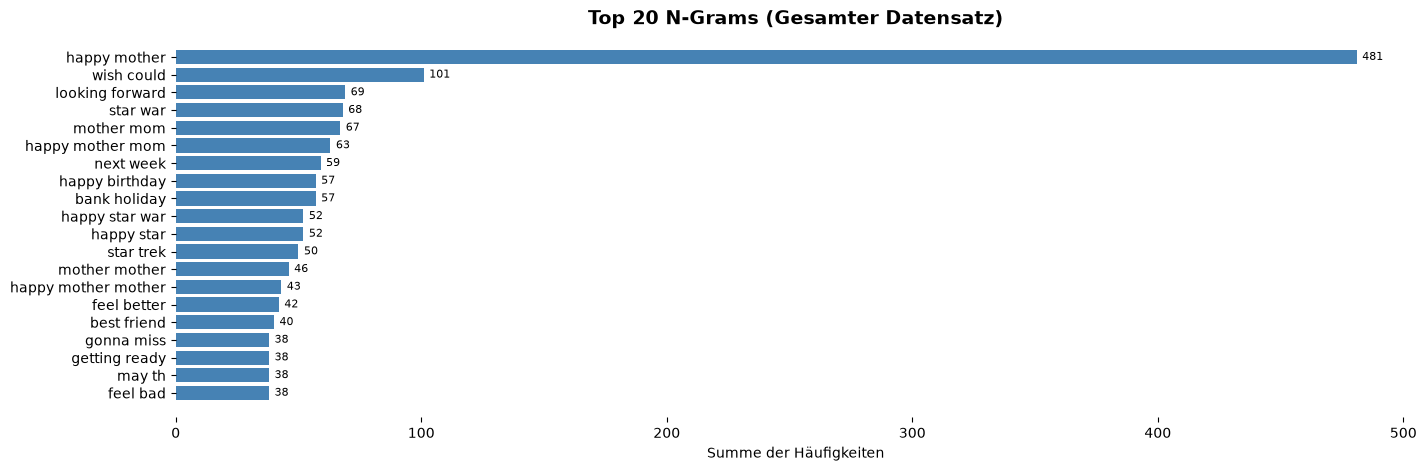

In [ ]:
top_idx = ngram_counts.argsort()[::-1][:20]
top_features = ngram_vectorizer.get_feature_names_out()[top_idx]
top_values = ngram_counts[top_idx]

fig, ax1 = plt.subplots(1, 1, figsize=(16, 5))

bars1 = ax1.barh(top_features[::-1], top_values[::-1], color="steelblue")
ax1.set_title("Top 20 N-grams (Gesamter Datensatz)", fontsize=14, fontweight="bold")
ax1.set_xlabel("Summe der Häufigkeiten")
ax1.bar_label(bars1, fmt="{:.0f}", padding=4, fontsize=8)
ax1.spines[:].set_visible(False)

plt.show()

Durch die N-grams werden häufige Wortzusammensetzungen sichtbar gemacht. Der Datensatz enthält besonders häufig "Happy mother" (481), "Mother mum" (67) und "Happy Mother Mom" (63)... Diese Kombinatation ist überproportional über mehrere Emotionklassen vertreten (siehe Grafik unten) und nicht trennscharf einer Emotion zuordbar. Auch vermindert diese Kombination die generalisierung auf andere Datensätze.

Woher kommt das? Die Vermutung (nach manueller durchsicht) ist das im zeitraum der Datenerhebung der Muttertag stattgefunden hat und viele Tweets diesen thematisieren. 

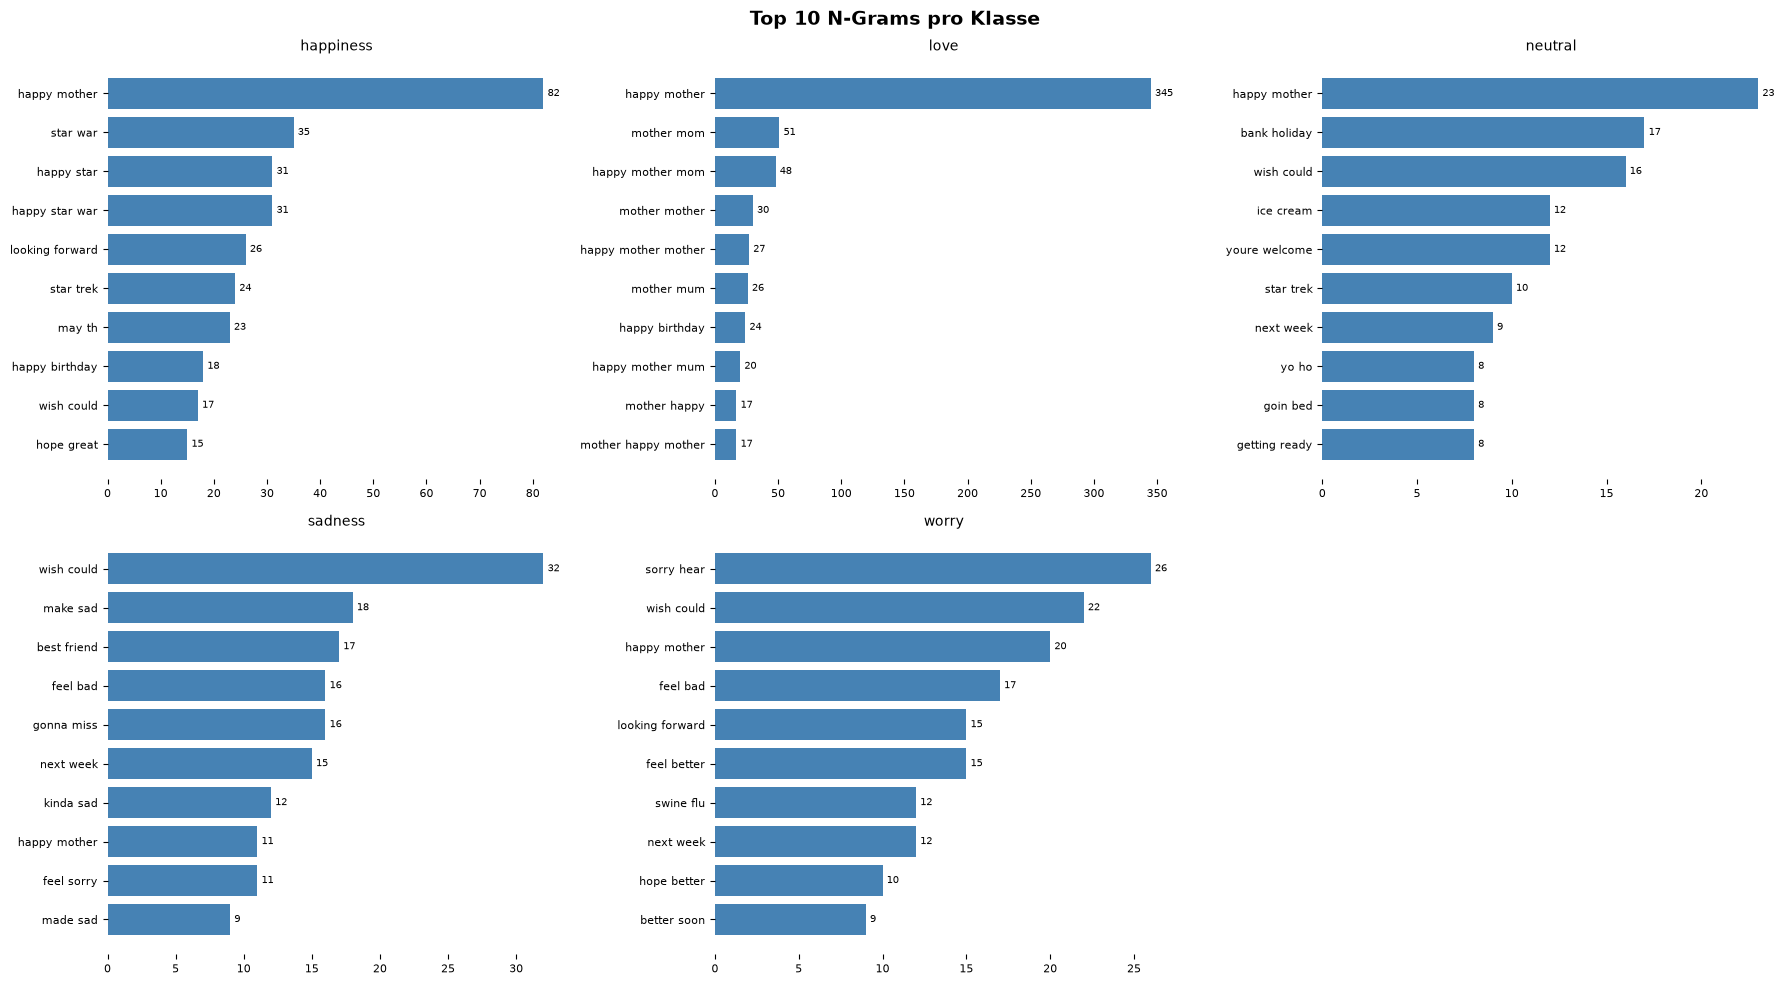

In [37]:
classes = sorted(y.unique())
ngram_names = ngram_vectorizer.get_feature_names_out()
y_train_arr = y.values

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
fig.suptitle("Top 10 N-Grams pro Klasse", fontsize=14, fontweight="bold")

for row, cls in enumerate(classes):
    mask = y_train_arr == cls

    cls_count = np.asarray(X_ngram[mask].sum(axis=0)).flatten()
    top_idx = cls_count.argsort()[::-1][:10]
    ax = axes[row]
    bars = ax.barh(ngram_names[top_idx][::-1], cls_count[top_idx][::-1], color="steelblue")
    ax.set_title(f"{cls}", fontsize=10)
    ax.bar_label(bars, fmt="{:.0f}", padding=3, fontsize=7)
    ax.spines[:].set_visible(False)
    ax.tick_params(labelsize=8)

for ax in axes[len(classes):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

In [39]:
# Mean count per class for every n-gram
class_scores = np.vstack([
    np.asarray(X_ngram[y_train_arr == cls].mean(axis=0)).flatten()
    for cls in classes
])  # shape: (n_classes, n_features)

# Only keep n-grams that appear in exactly one class
exclusive_mask = (class_scores > 0).sum(axis=0) == 1

unique_ngrams = {}
for i, cls in enumerate(classes):
    class_exclusive = exclusive_mask & (class_scores[i] > 0)
    candidate_idx = np.where(class_exclusive)[0]
    top_idx = candidate_idx[class_scores[i][candidate_idx].argsort()[::-1][:10]]
    unique_ngrams[cls] = ngram_names[top_idx].tolist()

pd.DataFrame(unique_ngrams)

,happiness,love,neutral,sadness,worry
0,great news,happy mother mama,yo ho,made sad,getting worse
1,said haha,say happy mother,put pic,low low,lost please
2,glad could,mom hope,talk tweet nba could,low low low,would never
3,hour drive,look cute,backup wife,yes week,lost please help find
4,water horse,genius happy,junior understand,super sad,look painful
5,first ever,mother dayyy,yo ho yo ho,starting ache,little sad
6,watching season,album truly,yo ho yo,last nite,sinus infection
7,sound delicious,album truly genius,yo ho another hell,low low low low,feel useless
8,make great,truly genius,yo ho another,bummed missing,whole body
9,first job,album truly genius happy,didnt watch,wanna sleep,please help find


# Step 4: Modellierung

## 6.0 Machine Learning - Aufgabe 6

## 6.1

**Inputvariablen:** Als Eingabe für die Modelle verwenden wir verschiedene Vektorrepräsentationen unseres der Trainingskorpera. Konkret vergleichen wir Bag-of-Words (mit dem CountVectorizer) und TF-IDF. Jeder Tweet wird dabei als Vektor repräsentiert, dessen Dimensionen den Häufigkeiten bzw. Gewichtungen der enthaltenen token entsprechen.

**Outputvariablen:** Die Zielvariable ist die Emotionskategorie eines Tweets. Das Modell ordnet jedem Eingabevektor eine dieser Klassen zu. Die Güte der Vorhersage wird anschließend anhand der Testdaten mit dem F1-Score gemessen, der Präzision und Recall über alle Klassen gleichgewichtig berücksichtigt.

## 6.2 Prediction vs. Inference

+ **Prediction:**  Unser Ziel ist die möglichst genaue Vorhersage (Prediction) der Emotion, nicht die Erklärung kausaler Zusammenhänge zwischen Features und Label wie bei Inference gefordert.

+ **Inference:**
Eine Frage wäre daher welche Inputvariable ( Wört) ein Indikator für eine spezifische Emotion ist und zu welcher Warscheinlichkeit. Die Wortfrequezanalyse 

## 6.3

+ **Classification vs. Regression:** Es handelt sich um eine Klassifikation, da die Zielvariablen aus Klassen besteht und keine kontinuierliche Werte vorhergesagt werden. 


## 7.1 Training und Test von Modellen

In [40]:
X_count_train, X_count_test, y_count_train, y_count_test = train_test_split(X_count, y, test_size=0.3, stratify=y, random_state=42)
X_tfidf_train, X_tfidf_test, y_tfidf_train, y_tfidf_test = train_test_split(X_tfidf, y, test_size=0.3, stratify=y, random_state=42)
X_count_ngram_train, X_count_ngram_test, y_count_ngram_train, y_count_ngram_test = train_test_split(X_count_ngram, y, test_size=0.3, stratify=y, random_state=42)
X_tfidf_ngram_train, X_tfidf_ngram_test, y_tfidf_ngram_train, y_tfidf_ngram_test = train_test_split(X_tfidf_ngram, y, test_size=0.3, stratify=y, random_state=42)

results = {}

### K Nearest Neighbor

In [41]:
k_values = [3, 7, 11, 15, 21, 31, 51]
feature_counts = [1000, 3000, 5000, 10000, None]
ngram_ranges = [(1, 1), (1, 2), (1, 3)]

best_score, best_k, best_features, best_ngram = 0, None, None, None

for ngram in ngram_ranges:
    for max_f in feature_counts:
        vec = CountVectorizer(max_features=max_f, ngram_range=ngram)
        X_cv_train = vec.fit_transform(corpus[y_count_train.index])

        for k in k_values:
            scores = cross_val_score(KNeighborsClassifier(n_neighbors=k), X_cv_train, y_count_train, cv=3, scoring="f1_macro")
            if scores.mean() > best_score:
                best_score = scores.mean()
                best_k = k
                best_features = max_f
                best_ngram = ngram

print(f"Bestes k:             {best_k}")
print(f"Beste Feature-Anzahl: {best_features}")
print(f"Bestes N-Gram:        {best_ngram}")
print(f"Bester F1 (CV):       {best_score:.3f}")

Bestes k:             3
Beste Feature-Anzahl: 5000
Bestes N-Gram:        (1, 1)
Bester F1 (CV):       0.353


In [74]:
# CV + KNN

model_count_knn = KNeighborsClassifier(n_neighbors=11).fit(X_count_train, y_count_train)
y_pred = model_count_knn.predict(X_count_test)
f1 = f1_score(y_count_test, y_pred, average="macro")

print("=== CountVectorizer + KNN ===")
print(classification_report(y_count_test, y_pred, zero_division=0))

results["CV + KNN"] = (f1, model_count_knn, X_count_test, y_count_test)

=== CountVectorizer + KNN ===
              precision    recall  f1-score   support

   happiness       0.33      0.39      0.36      1153
        love       0.42      0.36      0.39      1152
     neutral       0.27      0.58      0.37      1153
     sadness       0.52      0.25      0.34      1153
       worry       0.34      0.11      0.16      1152

    accuracy                           0.34      5763
   macro avg       0.38      0.34      0.32      5763
weighted avg       0.38      0.34      0.32      5763



In [75]:
# TF-IDF + KNN

model_tfidf_knn = KNeighborsClassifier(n_neighbors=11).fit(X_tfidf_train, y_tfidf_train)
y_pred = model_tfidf_knn.predict(X_tfidf_test)
f1 = f1_score(y_tfidf_test, y_pred, average="macro")

print("=== TF-IDF + KNN ===")
print(classification_report(y_tfidf_test, y_pred, zero_division=0))
results["TF-IDF + KNN"] = (f1, model_tfidf_knn, X_tfidf_test, y_tfidf_test)

=== TF-IDF + KNN ===
              precision    recall  f1-score   support

   happiness       0.34      0.27      0.30      1153
        love       0.39      0.34      0.37      1152
     neutral       0.22      0.65      0.33      1153
     sadness       0.45      0.12      0.19      1153
       worry       0.36      0.06      0.10      1152

    accuracy                           0.29      5763
   macro avg       0.35      0.29      0.26      5763
weighted avg       0.35      0.29      0.26      5763



In [76]:
# CV + Ngram + KNN

model_count_ngram_knn = KNeighborsClassifier(n_neighbors=11).fit(X_count_ngram_train, y_count_ngram_train)
y_pred = model_count_ngram_knn.predict(X_count_ngram_test)
f1 = f1_score(y_count_ngram_test, y_pred, average="macro")

print("=== CountVectorizer + Ngram + KNN ===")
print(classification_report(y_count_ngram_test, y_pred, zero_division=0))
results["CV + Ngram + KNN"] = (f1, model_count_ngram_knn, X_count_ngram_test, y_count_ngram_test)

=== CountVectorizer + Ngram + KNN ===
              precision    recall  f1-score   support

   happiness       0.40      0.40      0.40      1153
        love       0.38      0.40      0.39      1152
     neutral       0.27      0.59      0.37      1153
     sadness       0.53      0.25      0.34      1153
       worry       0.42      0.13      0.19      1152

    accuracy                           0.35      5763
   macro avg       0.40      0.35      0.34      5763
weighted avg       0.40      0.35      0.34      5763



In [77]:
# TF-IDF + Ngram + KNN

model_tfidf_ngram_knn = KNeighborsClassifier(n_neighbors=11).fit(X_tfidf_ngram_train, y_tfidf_ngram_train)
y_pred = model_tfidf_ngram_knn.predict(X_tfidf_ngram_test)
f1 = f1_score(y_tfidf_ngram_test, y_pred, average="macro")

print("=== TF-IDF + Ngram + KNN ===")
print(classification_report(y_tfidf_ngram_test, y_pred, zero_division=0))
results["TF-IDF + Ngram + KNN"] = (f1, model_tfidf_ngram_knn, X_tfidf_ngram_test, y_tfidf_ngram_test)

=== TF-IDF + Ngram + KNN ===
              precision    recall  f1-score   support

   happiness       0.35      0.27      0.31      1153
        love       0.40      0.34      0.37      1152
     neutral       0.24      0.70      0.35      1153
     sadness       0.45      0.12      0.19      1153
       worry       0.37      0.06      0.11      1152

    accuracy                           0.30      5763
   macro avg       0.36      0.30      0.26      5763
weighted avg       0.36      0.30      0.26      5763



### Decision Tree

In [90]:
# CV + DT

model_count_dt = DecisionTreeClassifier(class_weight="balanced", min_samples_leaf=18, random_state=42).fit(X_count_train, y_count_train)
y_pred = model_count_dt.predict(X_count_test)
f1 = f1_score(y_count_test, y_pred, average="macro")

print("=== CountVectorizer + DecisionTree ===")
print(classification_report(y_count_test, y_pred, zero_division=0))
results["CV + DT"] = (f1, model_count_dt, X_count_test, y_count_test)

=== CountVectorizer + DecisionTree ===
              precision    recall  f1-score   support

   happiness       0.39      0.44      0.42      1153
        love       0.48      0.38      0.42      1152
     neutral       0.33      0.42      0.37      1153
     sadness       0.42      0.47      0.44      1153
       worry       0.38      0.26      0.31      1152

    accuracy                           0.40      5763
   macro avg       0.40      0.40      0.39      5763
weighted avg       0.40      0.40      0.39      5763



In [91]:
# TF-IDF + DT

model_tfidf_dt = DecisionTreeClassifier(class_weight="balanced", min_samples_leaf=18, random_state=42).fit(X_tfidf_train, y_tfidf_train)
y_pred = model_tfidf_dt.predict(X_tfidf_test)
f1 = f1_score(y_tfidf_test, y_pred, average="macro")

print("=== TF-IDF + DecisionTree ===")
print(classification_report(y_tfidf_test, y_pred, zero_division=0))
results["TF-IDF + DT"] = (f1, model_tfidf_dt, X_tfidf_test, y_tfidf_test)

=== TF-IDF + DecisionTree ===
              precision    recall  f1-score   support

   happiness       0.39      0.39      0.39      1153
        love       0.46      0.40      0.43      1152
     neutral       0.33      0.47      0.39      1153
     sadness       0.43      0.40      0.41      1153
       worry       0.34      0.26      0.29      1152

    accuracy                           0.38      5763
   macro avg       0.39      0.38      0.38      5763
weighted avg       0.39      0.38      0.38      5763



In [92]:
# CV + Ngram + DT

model_count_ngram_dt = DecisionTreeClassifier(class_weight="balanced", min_samples_leaf=18, random_state=42).fit(X_count_ngram_train, y_count_ngram_train)
y_pred = model_count_ngram_dt.predict(X_count_ngram_test)
f1 = f1_score(y_count_ngram_test, y_pred, average="macro")

print("=== CountVectorizer + Ngram + DecisionTree ===")
print(classification_report(y_count_ngram_test, y_pred, zero_division=0))
results["CV + Ngram + DT"] = (f1, model_count_ngram_dt, X_count_ngram_test, y_count_ngram_test)

=== CountVectorizer + Ngram + DecisionTree ===
              precision    recall  f1-score   support

   happiness       0.38      0.42      0.40      1153
        love       0.49      0.38      0.42      1152
     neutral       0.33      0.42      0.37      1153
     sadness       0.42      0.45      0.44      1153
       worry       0.36      0.28      0.31      1152

    accuracy                           0.39      5763
   macro avg       0.40      0.39      0.39      5763
weighted avg       0.40      0.39      0.39      5763



In [93]:
# TF-IDF + Ngram + DT

model_tfidf_ngram_dt = DecisionTreeClassifier(class_weight="balanced", min_samples_leaf=18, random_state=42).fit(X_tfidf_ngram_train, y_tfidf_ngram_train)
y_pred = model_tfidf_ngram_dt.predict(X_tfidf_ngram_test)
f1 = f1_score(y_tfidf_ngram_test, y_pred, average="macro")

print("=== TF-IDF + Ngram + DecisionTree ===")
print(classification_report(y_tfidf_ngram_test, y_pred, zero_division=0))
results["TF-IDF + Ngram + DT"] = (f1, model_tfidf_ngram_dt, X_tfidf_ngram_test, y_tfidf_ngram_test)

=== TF-IDF + Ngram + DecisionTree ===
              precision    recall  f1-score   support

   happiness       0.36      0.37      0.36      1153
        love       0.46      0.40      0.42      1152
     neutral       0.32      0.46      0.38      1153
     sadness       0.44      0.41      0.42      1153
       worry       0.35      0.26      0.30      1152

    accuracy                           0.38      5763
   macro avg       0.38      0.38      0.38      5763
weighted avg       0.38      0.38      0.38      5763



### Random forest

In [ ]:
# CV + RF

model_count_rf = RandomForestClassifier(n_estimators=50, class_weight="balanced", random_state=42).fit(X_count_train, y_count_train)
y_pred = model_count_rf.predict(X_count_test)
f1 = f1_score(y_count_test, y_pred, average="macro")

print("=== CountVectorizer + RandomForest ===")
print(classification_report(y_count_test, y_pred, zero_division=0))
results["CV + RF"] = (f1, model_count_rf, X_count_test, y_count_test)

=== CountVectorizer + RandomForest ===
              precision    recall  f1-score   support

   happiness       0.60      0.63      0.61      1153
        love       0.63      0.66      0.64      1152
     neutral       0.45      0.53      0.49      1153
     sadness       0.64      0.58      0.61      1153
       worry       0.54      0.44      0.49      1152

    accuracy                           0.57      5763
   macro avg       0.57      0.57      0.57      5763
weighted avg       0.57      0.57      0.57      5763



In [78]:
# TF-IDF + RF

model_tfidf_rf = RandomForestClassifier(n_estimators=50, class_weight="balanced", random_state=42).fit(X_tfidf_train, y_tfidf_train)
y_pred = model_tfidf_rf.predict(X_tfidf_test)
f1 = f1_score(y_tfidf_test, y_pred, average="macro")

print("=== TF-IDF + RandomForest ===")
print(classification_report(y_tfidf_test, y_pred, zero_division=0))
results["TF-IDF + RF"] = (f1, model_tfidf_rf, X_tfidf_test, y_tfidf_test)

=== TF-IDF + RandomForest ===
              precision    recall  f1-score   support

   happiness       0.61      0.65      0.63      1153
        love       0.69      0.67      0.68      1152
     neutral       0.48      0.56      0.52      1153
     sadness       0.63      0.61      0.62      1153
       worry       0.55      0.46      0.50      1152

    accuracy                           0.59      5763
   macro avg       0.59      0.59      0.59      5763
weighted avg       0.59      0.59      0.59      5763



In [ ]:
# CV + Ngram + RF

model_count_ngram_rf = RandomForestClassifier(n_estimators=50, class_weight="balanced", random_state=42).fit(X_count_ngram_train, y_count_ngram_train)
y_pred = model_count_ngram_rf.predict(X_count_ngram_test)
f1 = f1_score(y_count_ngram_test, y_pred, average="macro")

print("=== CountVectorizer + Ngram + RandomForest ===")
print(classification_report(y_count_ngram_test, y_pred, zero_division=0))
results["CV + Ngram + RF"] = (f1, model_count_ngram_rf, X_count_ngram_test, y_count_ngram_test)

=== CountVectorizer + Ngram + RandomForest ===
              precision    recall  f1-score   support

   happiness       0.59      0.63      0.61      1153
        love       0.63      0.66      0.64      1152
     neutral       0.45      0.54      0.49      1153
     sadness       0.66      0.59      0.62      1153
       worry       0.55      0.43      0.48      1152

    accuracy                           0.57      5763
   macro avg       0.58      0.57      0.57      5763
weighted avg       0.58      0.57      0.57      5763



In [ ]:
# TF-IDF + Ngram + RF

model_tfidf_ngram_rf = RandomForestClassifier(n_estimators=50, class_weight="balanced", random_state=42, n_jobs=-1).fit(X_tfidf_ngram_train, y_tfidf_ngram_train)
y_pred = model_tfidf_ngram_rf.predict(X_tfidf_ngram_test)
f1 = f1_score(y_tfidf_ngram_test, y_pred, average="macro")

print("=== TF-IDF + Ngram + RandomForest ===")
print(classification_report(y_tfidf_ngram_test, y_pred, zero_division=0))
results["TF-IDF + Ngram + RF"] = (f1, model_tfidf_ngram_rf, X_tfidf_ngram_test, y_tfidf_ngram_test)

=== TF-IDF + Ngram + RandomForest ===
              precision    recall  f1-score   support

   happiness       0.61      0.66      0.63      1153
        love       0.70      0.65      0.68      1152
     neutral       0.49      0.58      0.53      1153
     sadness       0.63      0.62      0.63      1153
       worry       0.58      0.45      0.51      1152

    accuracy                           0.60      5763
   macro avg       0.60      0.60      0.59      5763
weighted avg       0.60      0.60      0.59      5763



### Neuronales Netz (MLP)

In [58]:
hidden_layer_options = [(32,), (64,), (128,), (32, 32), (32, 64), (64, 64), (64, 128), (128, 64), (128, 32)]

best_score, best_layers = 0, None

for layers in hidden_layer_options:
    score = f1_score(y_tfidf_test, MLPClassifier(hidden_layer_sizes=layers, early_stopping=True, random_state=42).fit(X_tfidf_train, y_tfidf_train).predict(X_tfidf_test), average="macro")
    if score > best_score:
        best_score = score
        best_layers = layers

print(f"Beste Hidden Layers: {best_layers}")
print(f"Bester F1 (Test):    {best_score:.3f}")

Beste Hidden Layers: (128, 64)
Bester F1 (Test):    0.542


In [83]:
# CV + MLP

model_count_mlp = MLPClassifier(hidden_layer_sizes=best_layers, early_stopping=True, random_state=42).fit(X_count_train, y_count_train)
y_pred = model_count_mlp.predict(X_count_test)
f1 = f1_score(y_count_test, y_pred, average="macro")

print("=== CountVectorizer + MLP ===")
print(classification_report(y_count_test, y_pred, zero_division=0))
results["CV + MLP"] = (f1, model_count_mlp, X_count_test, y_count_test)

=== CountVectorizer + MLP ===
              precision    recall  f1-score   support

   happiness       0.60      0.56      0.58      1153
        love       0.62      0.67      0.64      1152
     neutral       0.45      0.50      0.47      1153
     sadness       0.57      0.55      0.56      1153
       worry       0.50      0.45      0.47      1152

    accuracy                           0.55      5763
   macro avg       0.55      0.55      0.55      5763
weighted avg       0.55      0.55      0.55      5763



In [84]:
# TF-IDF + MLP

model_tfidf_mlp = MLPClassifier(hidden_layer_sizes=best_layers, early_stopping=True, random_state=42).fit(X_tfidf_train, y_tfidf_train)
y_pred = model_tfidf_mlp.predict(X_tfidf_test)
f1 = f1_score(y_tfidf_test, y_pred, average="macro")

print("=== TF-IDF + MLP ===")
print(classification_report(y_tfidf_test, y_pred, zero_division=0))
results["TF-IDF + MLP"] = (f1, model_tfidf_mlp, X_tfidf_test, y_tfidf_test)

=== TF-IDF + MLP ===
              precision    recall  f1-score   support

   happiness       0.57      0.61      0.59      1153
        love       0.63      0.64      0.63      1152
     neutral       0.46      0.47      0.46      1153
     sadness       0.56      0.54      0.55      1153
       worry       0.49      0.46      0.48      1152

    accuracy                           0.54      5763
   macro avg       0.54      0.54      0.54      5763
weighted avg       0.54      0.54      0.54      5763



In [85]:
# CV + Ngram + MLP

model_count_ngram_mlp = MLPClassifier(hidden_layer_sizes=best_layers, early_stopping=True, random_state=42).fit(X_count_ngram_train, y_count_ngram_train)
y_pred = model_count_ngram_mlp.predict(X_count_ngram_test)
f1 = f1_score(y_count_ngram_test, y_pred, average="macro")

print("=== CountVectorizer + Ngram + MLP ===")
print(classification_report(y_count_ngram_test, y_pred, zero_division=0))
results["CV + Ngram + MLP"] = (f1, model_count_ngram_mlp, X_count_ngram_test, y_count_ngram_test)

=== CountVectorizer + Ngram + MLP ===
              precision    recall  f1-score   support

   happiness       0.55      0.60      0.58      1153
        love       0.65      0.58      0.61      1152
     neutral       0.43      0.50      0.47      1153
     sadness       0.59      0.54      0.56      1153
       worry       0.50      0.46      0.48      1152

    accuracy                           0.54      5763
   macro avg       0.54      0.54      0.54      5763
weighted avg       0.54      0.54      0.54      5763



In [86]:
# TF-IDF + Ngram + MLP

model_tfidf_ngram_mlp = MLPClassifier(hidden_layer_sizes=best_layers, early_stopping=True, random_state=42).fit(X_tfidf_ngram_train, y_tfidf_ngram_train)
y_pred = model_tfidf_ngram_mlp.predict(X_tfidf_ngram_test)
f1 = f1_score(y_tfidf_ngram_test, y_pred, average="macro")

print("=== TF-IDF + Ngram + MLP ===")
print(classification_report(y_tfidf_ngram_test, y_pred, zero_division=0))
results["TF-IDF + Ngram + MLP"] = (f1, model_tfidf_ngram_mlp, X_tfidf_ngram_test, y_tfidf_ngram_test)

=== TF-IDF + Ngram + MLP ===
              precision    recall  f1-score   support

   happiness       0.57      0.58      0.57      1153
        love       0.62      0.61      0.61      1152
     neutral       0.44      0.48      0.46      1153
     sadness       0.56      0.57      0.56      1153
       worry       0.50      0.44      0.47      1152

    accuracy                           0.54      5763
   macro avg       0.54      0.54      0.53      5763
weighted avg       0.54      0.54      0.53      5763



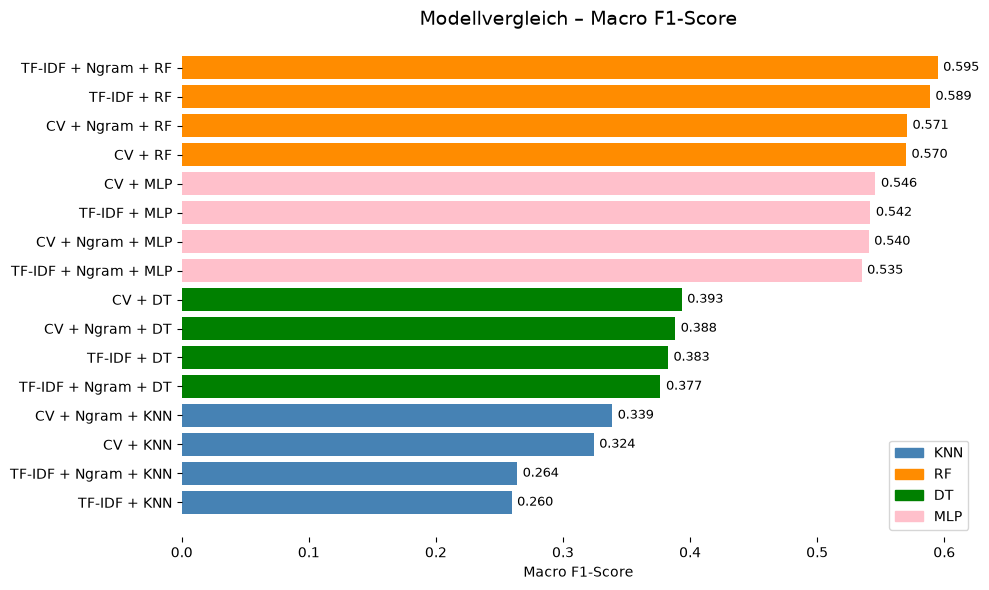

In [87]:
results_df = pd.Series({k: v[0] for k, v in results.items()}).sort_values()
color_map = {"KNN": "steelblue", "RF": "darkorange", "DT": "green", "MLP" : "pink"}
colors = [next(c for k, c in color_map.items() if k in name) for name in results_df.index]

_, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(results_df.index, results_df.values, color=colors)
ax.set_title("Modellvergleich – Macro F1-Score", fontsize=14)
ax.set_xlabel("Macro F1-Score")
ax.bar_label(bars, fmt="{:.3f}", padding=4, fontsize=9)
ax.spines[:].set_visible(False)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=c, label=k) for k, c in color_map.items()], loc="lower right")

plt.tight_layout()
plt.show()

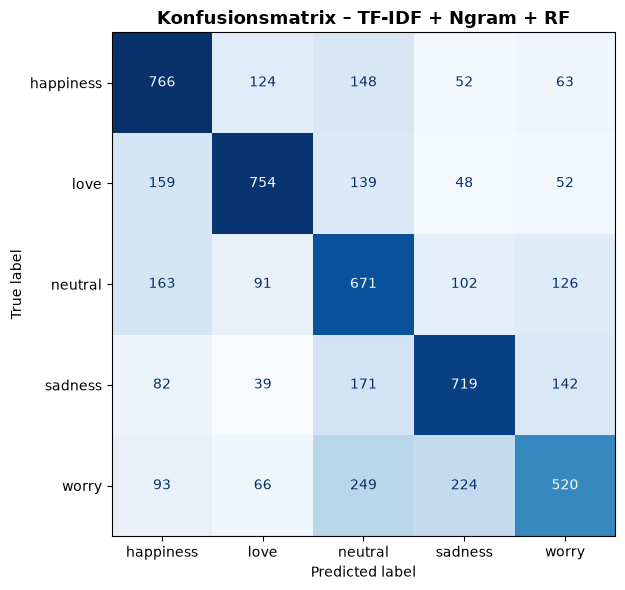

In [64]:
best_name = results_df.index[-1]
_, best_model, X_test_best, y_test_best = results[best_name]
y_pred_best = best_model.predict(X_test_best)

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test_best, y_pred_best, ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Konfusionsmatrix – {best_name}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Step 5: Evaluation